In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline

# **Analysis of Data**

In [3]:
df = pd.read_csv("C:/Users/Sam Nathan/Downloads/Mental_Health_and_Social_Media_Balance_Dataset.csv")

In [4]:
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [5]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time(hrs)',
       'Sleep_Quality(1-10)', 'Stress_Level(1-10)',
       'Days_Without_Social_Media', 'Exercise_Frequency(week)',
       'Social_Media_Platform', 'Happiness_Index(1-10)'],
      dtype='object')

In [6]:
df.shape

(500, 10)

In [7]:
df.dtypes

User_ID                       object
Age                            int64
Gender                        object
Daily_Screen_Time(hrs)       float64
Sleep_Quality(1-10)          float64
Stress_Level(1-10)           float64
Days_Without_Social_Media    float64
Exercise_Frequency(week)     float64
Social_Media_Platform         object
Happiness_Index(1-10)        float64
dtype: object

In [8]:
df.isnull().sum()

User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64



---



# **Distribution of Column Data and Analysis**

***Gender***

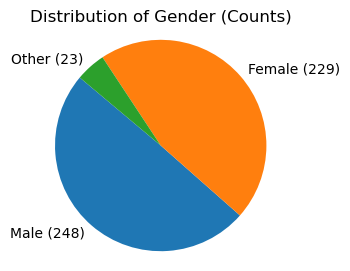

In [9]:
gender_counts = df['Gender'].value_counts()
# Create custom labels including the count
labels = [f'{gender} ({count})' for gender, count in zip(gender_counts.index, gender_counts.values)]

plt.figure(figsize=(3, 3))
plt.pie(gender_counts, labels=labels, startangle=140)
plt.title('Distribution of Gender (Counts)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

***Age***

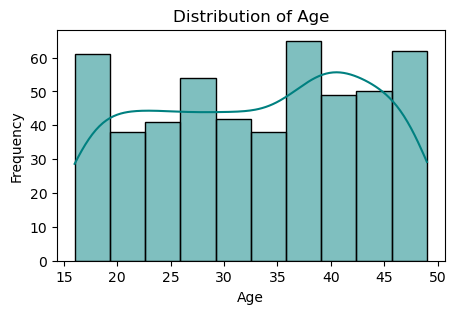

In [10]:
plt.figure(figsize=(5, 3))
sns.histplot(df['Age'], kde=True,color='teal')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


***Daily Screen Time***

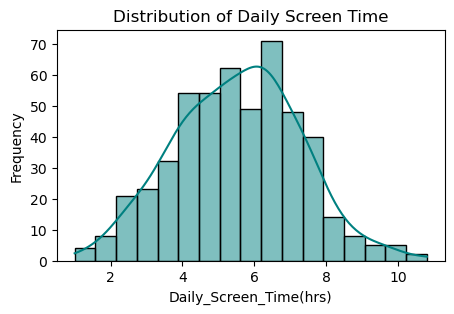

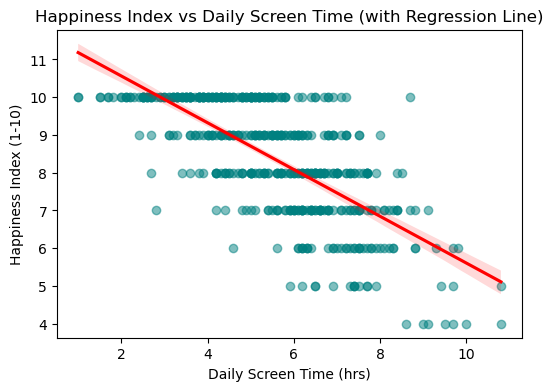

In [11]:
plt.figure(figsize=(5, 3))
sns.histplot(df['Daily_Screen_Time(hrs)'], kde=True, color='teal')
plt.title('Distribution of Daily Screen Time')
plt.xlabel('Daily_Screen_Time(hrs)')
plt.ylabel('Frequency')
plt.show()

# Visualize the relationship between 'Daily_Screen_Time(hrs)' and 'Happiness_Index(1-10)'
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='Daily_Screen_Time(hrs)', y='Happiness_Index(1-10)', scatter_kws={'alpha': 0.5, 'color': 'teal'}, line_kws={'color': 'red'})
plt.title('Happiness Index vs Daily Screen Time (with Regression Line)')
plt.xlabel('Daily Screen Time (hrs)')
plt.ylabel('Happiness Index (1-10)')
plt.show()

***Sleep Quality***

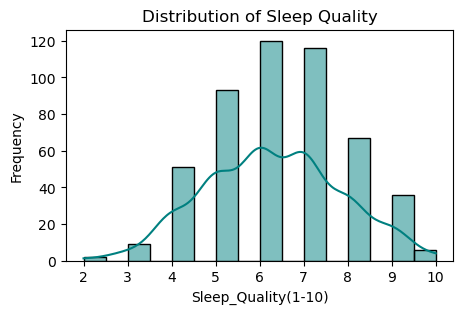

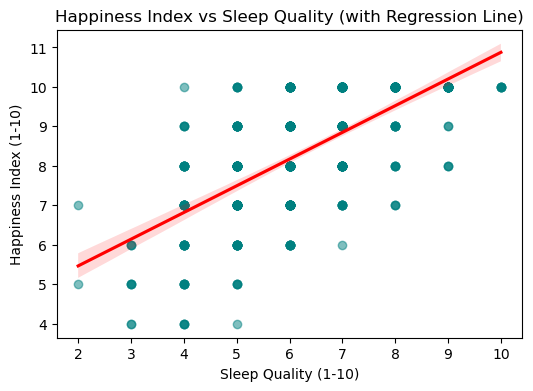

In [12]:
plt.figure(figsize=(5, 3))
sns.histplot(df['Sleep_Quality(1-10)'], kde=True, color='teal')
plt.title('Distribution of Sleep Quality')
plt.xlabel('Sleep_Quality(1-10)')
plt.ylabel('Frequency')
plt.show()
# Visualize the relationship between 'Sleep_Quality(1-10)' and 'Happiness_Index(1-10)'
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='Sleep_Quality(1-10)', y='Happiness_Index(1-10)', scatter_kws={'alpha': 0.5, 'color': 'teal'}, line_kws={'color': 'red'})
plt.title('Happiness Index vs Sleep Quality (with Regression Line)')
plt.xlabel('Sleep Quality (1-10)')
plt.ylabel('Happiness Index (1-10)')
plt.show()

***Stress Level***

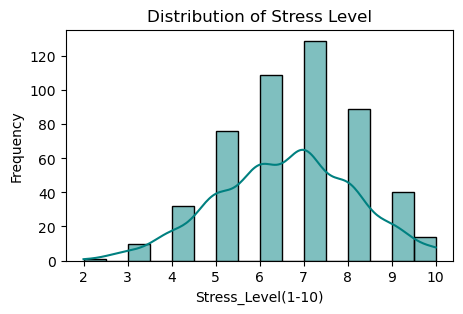

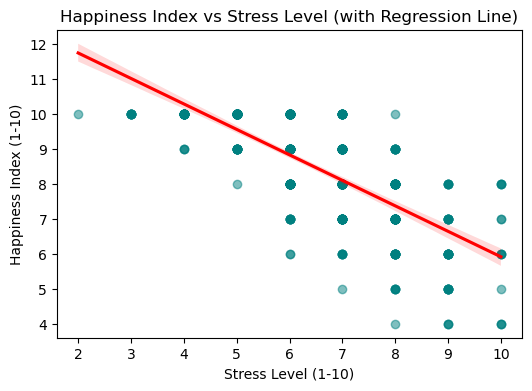

In [13]:
plt.figure(figsize=(5, 3))
sns.histplot(df['Stress_Level(1-10)'], kde=True, color='teal')
plt.title('Distribution of Stress Level')
plt.xlabel('Stress_Level(1-10)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='Stress_Level(1-10)', y='Happiness_Index(1-10)', scatter_kws={'alpha': 0.5, 'color': 'teal'}, line_kws={'color': 'red'})
plt.title('Happiness Index vs Stress Level (with Regression Line)')
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Happiness Index (1-10)')
plt.show()

***Days Without Social Media***

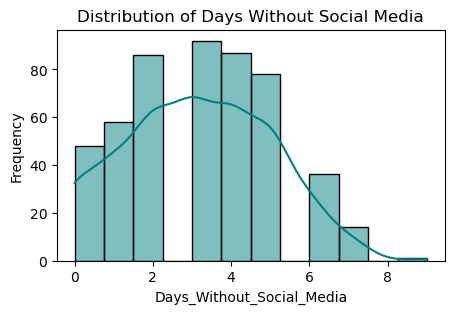

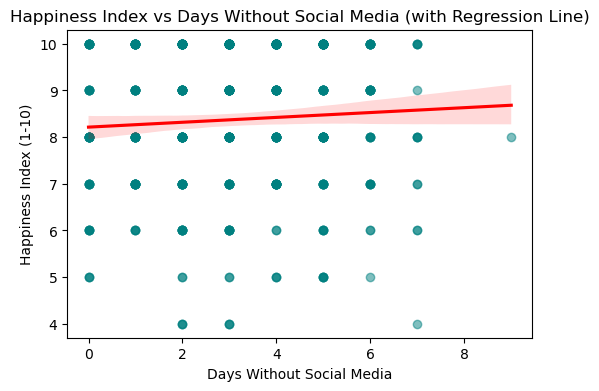

In [14]:
plt.figure(figsize=(5, 3))
sns.histplot(df['Days_Without_Social_Media'], kde=True, color='teal')
plt.title('Distribution of Days Without Social Media')
plt.xlabel('Days_Without_Social_Media')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='Days_Without_Social_Media', y='Happiness_Index(1-10)', scatter_kws={'alpha': 0.5, 'color': 'teal'}, line_kws={'color': 'red'})
plt.title('Happiness Index vs Days Without Social Media (with Regression Line)')
plt.xlabel('Days Without Social Media')
plt.ylabel('Happiness Index (1-10)')
plt.show()

***Exercise Frequency***

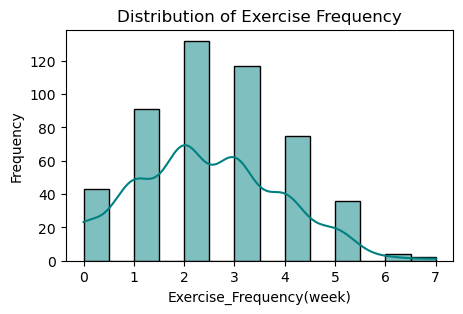

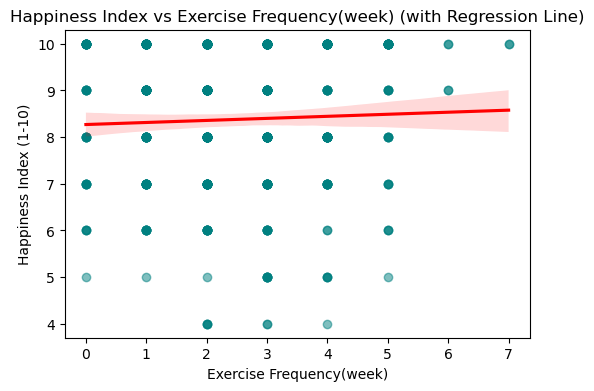

In [15]:
plt.figure(figsize=(5, 3))
sns.histplot(df['Exercise_Frequency(week)'], kde=True, color='teal')
plt.title('Distribution of Exercise Frequency')
plt.xlabel('Exercise_Frequency(week)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='Exercise_Frequency(week)', y='Happiness_Index(1-10)', scatter_kws={'alpha': 0.5, 'color': 'teal'}, line_kws={'color': 'red'})
plt.title('Happiness Index vs Exercise Frequency(week) (with Regression Line)')
plt.xlabel('Exercise Frequency(week)')
plt.ylabel('Happiness Index (1-10)')
plt.show()

***Social Media Platform***

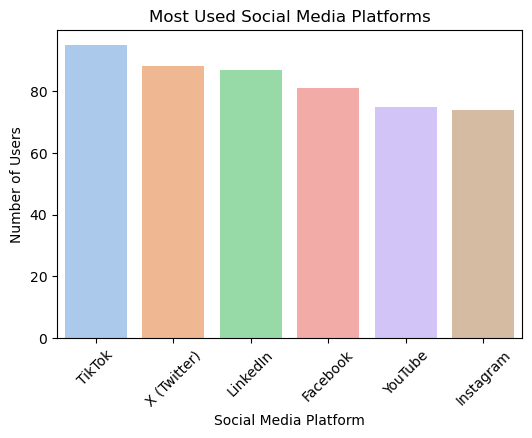

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Social_Media_Platform', data=df, palette='pastel',
              order=df['Social_Media_Platform'].value_counts().index)

plt.title('Most Used Social Media Platforms')
plt.xlabel('Social Media Platform')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()

***Which variables are most correlated with Happiness_Index?***

In [17]:
X = df[['Daily_Screen_Time(hrs)','Sleep_Quality(1-10)','Stress_Level(1-10)','Days_Without_Social_Media','Exercise_Frequency(week)']]
y = df['Happiness_Index(1-10)']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Happiness_Index(1-10)   R-squared:                       0.643
Model:                               OLS   Adj. R-squared:                  0.640
Method:                    Least Squares   F-statistic:                     178.1
Date:                   Mon, 12 Jan 2026   Prob (F-statistic):          4.12e-108
Time:                           16:12:13   Log-Likelihood:                -662.03
No. Observations:                    500   AIC:                             1336.
Df Residuals:                        494   BIC:                             1361.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

***Explanation***

🟢 **Daily Screen Time (hrs)**

Coefficient = −0.106
p = 0.017 (significant)

Interpretation:
Each additional 1 hour of screen time is associated with a 0.106 decrease in happiness score, keeping other factors constant.

Insight:
Higher screen time → lower happiness

🔴 **Sleep Quality (1–10)**

Coefficient = +0.313
p < 0.001 (highly significant)

Interpretation:
A 1-point improvement in sleep quality increases happiness by 0.31 units on average.

Insight:
Sleep quality is a strong positive predictor of happiness

🔴 **Stress Level (1–10)**

Coefficient = −0.458
p < 0.001 (highly significant)

Interpretation:
A 1-point increase in stress reduces happiness by 0.46 units.

Insight:
Stress has the strongest negative impact on happiness among all variables.

⚪ **Days Without Social Media**

Coefficient = +0.034
p = 0.123 (NOT significant)

Interpretation:
Although the coefficient is positive, the effect is not statistically reliable.

Insight:
Simply staying off social media does not significantly affect happiness when other factors are considered.

⚪ **Exercise Frequency (week)**

Coefficient = +0.013
p = 0.658 (NOT significant)

Interpretation:
Exercise frequency shows no significant direct relationship with happiness in this dataset.

Insight:
Exercise may influence happiness indirectly (via sleep or stress).

# **Predictive Model**

In [18]:
X = df[['Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)', 'Stress_Level(1-10)',
        'Days_Without_Social_Media', 'Exercise_Frequency(week)']]
y = df['Happiness_Index(1-10)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

***Linear Regression***

In [19]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [20]:
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))


Linear Regression R²: 0.6108087460495468
Linear Regression RMSE: 0.9615418570632778
Linear Regression MAE: 0.8135999358259958


***Random Forest***

In [21]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [22]:
print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest R²: 0.6359863426178478
Random Forest RMSE: 0.9299198054010038
Random Forest MAE: 0.7480091666666666


***Gradient Boosting***

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=200,learning_rate=0.05,random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

In [24]:
print("Gradient Boosting R²:", r2_score(y_test, y_pred_gbr))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, y_pred_gbr))

Gradient Boosting R²: 0.6272571040499918
Gradient Boosting RMSE: 0.9410037319898575
Gradient Boosting MAE: 0.7618474086863333


***Explanation***

1️⃣ Compare the models (metric by metric)

🔹 **R² (higher is better)**

Linear Regression	0.611

Random Forest	0.636 ⭐

Gradient Boosting	0.627

➡ Random Forest explains the most variance in happiness.

🔹 **RMSE (lower is better)**

Linear Regression	0.962

Random Forest	0.930 ⭐

Gradient Boosting	0.941

➡ Random Forest has the smallest large-error penalty.

🔹 **MAE (lower is better)**

Linear Regression	0.814

Random Forest	0.748 ⭐

Gradient Boosting	0.762

➡ Random Forest makes the smallest average mistake.

# **User-Interactive Happiness Predictor**

In [25]:
model = rf   # Random Forest model you trained


In [26]:
def predict_happiness():
    print("\nEnter your details:\n")
    
    screen_time = float(input(
        "On average, how many hours per day do you spend on screens (mobile, laptop, TV)? "
    ))

    sleep = float(input(
        "How would you rate your overall sleep quality on a scale of 1 (very poor) to 10 (excellent)? "
    ))

    stress = float(input(
        "How would you rate your current stress level on a scale of 1 (no stress) to 10 (extreme stress)? "
    ))

    days_no_sm = float(input(
        "In the past week, how many days did you completely avoid using social media? "
    ))

    exercise = float(input(
        "How many days per week do you engage in physical exercise (walking, gym, sports, yoga)? "
    ))

    platform = input(
        "Which social media platform do you use the most? (e.g., Instagram, WhatsApp, YouTube): "
    )


    user_data = [[screen_time, sleep, stress, days_no_sm, exercise]]

    hi = model.predict(user_data)[0]

    print("\n---------------------------")
    print(f"Predicted Happiness Index: {hi:.2f}")

    # Rating
    if hi <= 4:
        level = "Very Bad 😞"
    elif hi < 6:
        level = "Bad 😕"
    elif hi < 8:
        level = "Good 🙂"
    else:
        level = "Very Good 😄"

    print("Happiness Level:", level)

    # Suggestions
    print("\nSuggestions to Improve:")
    
    if sleep < 6:
        print("- Improve sleep quality (consistent sleep schedule)")
    if stress > 6:
        print("- Focus on stress management (meditation, breaks)")
    if screen_time > 6:
        print("- Reduce daily screen time")
    if exercise < 3:
        print("- Increase physical activity")
    if days_no_sm < 2:
        print("- Try short social media detox periods")

    print(f"- Be mindful of excessive use of {platform}")


In [28]:
predict_happiness()


Enter your details:


---------------------------
Predicted Happiness Index: 8.08
Happiness Level: Very Good 😄

Suggestions to Improve:
- Focus on stress management (meditation, breaks)
- Try short social media detox periods
- Be mindful of excessive use of Instagram


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
